# Forced Short Covering in Taiwan (融券強制回補)

**Thesis.** Before every shareholder meeting and ex-dividend / ex-rights book closure, TWSE bans new short
sales and forces every existing margin short (融券) to be bought back by a fixed deadline. The deadline is
public days in advance, the buying is non-discretionary, and Taiwanese demand is inelastic (GIV study:
~18% price impact per 1% of market cap). Stocks with a lot of short interest relative to volume should
see buying pressure into the deadline, and possibly give it back afterwards.

This is the same shape as the Gotobi pitch: a known calendar date, a mechanical flow, and a test of
whether the flow moves price beyond what randomly chosen dates do.

**Data** (all pulled by `collect_twse.py` / `collect_finmind.py`, 2018-01 → 2026-09)

| file | source | what |
|---|---|---|
| `prices.csv` | TWSE MI_INDEX | daily OHLCV, every listed stock |
| `exdiv.csv` | TWSE TWT49U | ex-rights / ex-dividend reference prices, for dividend-adjusted returns |
| `index.csv` | TWSE MI_INDEX | TAIEX price and total-return index |
| `margin.csv` | TWSE MI_MARGN | daily margin (融資) and short (融券) balances, in lots of 1,000 shares |
| `suspension.csv` | FinMind | short-sale ban windows with the reason (AGM / ex-div / ex-rights) |
| `stock_futures.csv` | FinMind | single-stock futures, the tax-cheap way to trade it |

**Plan**
1. Prove the mechanism: short balances collapse to zero by a deterministic deadline.
2. Event study around the deadline, sorted by short pressure (days-to-cover).
3. Significance: date-clustered bootstrap, within-date long-short, panel regression, calendar-shift and
   random-date placebos.
4. Robustness splits: reason, year, size, in-sample vs out-of-sample.
5. Tradability: stock futures vs stock, costs, parameter grid, OOS backtest — both the long run-up into
   the deadline and the short reversal after it.

**Realism rules used throughout**
* **Information lag.** TWSE publishes the day's margin/short balances in the evening, after the close.
  A balance dated *t* can only drive a trade entered at the close of *t+1*, so its first usable return
  is *t+2*. Every signal below respects that (the first draft sorted on the balance of the day before the
  deadline and measured returns over the week before it, which is look-ahead: Taiwanese retail shorts
  pile into stocks that are rising, so a high balance at D−1 partly *records* the run-up).
* **Benchmark.** TAIEX is cap-weighted and ~40% TSMC; it beat the equal-weighted stock universe by
  ~20%/yr over 2022–26, which makes almost every stock's TAIEX-adjusted return drift down. Event-study
  returns use the equal-weighted universe as the market; the backtest uses TAIEX, because a TX future
  is the hedge you can actually trade.
* **Cross-section.** The headline test is high-minus-low short pressure among events that share a deadline
  date, which removes AGM/ex-div seasonality entirely.
* **Tradability.** Margin shorts cannot be opened during the ban, so a stock short waits for the ban to
  end; single-stock futures can be shorted any day. Backtest trades need NT$20m/day of turnover.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import statsmodels.formula.api as smf

plt.rcParams.update({"figure.figsize": (10, 4.5), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
DATA = Path("data")

IS_END = pd.Timestamp("2023-12-31")   # in-sample 2018-2023, out-of-sample 2024-2026
PRE, POST = 15, 15                    # event window, trading days around the covering deadline
SIG_LAG = 7                           # signal = balance at D-7: published evening D-7, enter close D-6, first return D-5
COST_STOCK_BPS = 55                   # 30 sell tax + ~2x4 discounted commission + ~2x8 slippage in mid/small caps
COST_SHORT_BPS = COST_STOCK_BPS + 10  # margin-short / SBL borrow fee and recall risk on top
COST_FUT_BPS = 20                     # ~0.4 futures tax + commission + a full tick of spread on thin stock futures
MIN_VAL20 = 2e7                       # tradability: NT$20m/day average turnover

for f in ["_twse.log", "_finmind.log"]:
    p = DATA / f
    print(f, "->", p.read_text().strip().splitlines()[-1] if p.exists() else "missing")
print("TWSE pull finished:", (DATA / "_twse_finished.flag").exists())

_twse.log -> 20220304: 1157 px, 1084 margin  [1141/2230]
_finmind.log ->     TaiwanStockMarginShortSaleSuspension: gave up after 6 retries; sleeping 15 min
TWSE pull finished: False


## 0. Load and build the panel

In [2]:
is_stock = lambda s: s.str.fullmatch(r"[1-9]\d{3}")

# --- prices + dividend-adjusted returns ---
px = pd.read_csv(DATA / "prices.csv", dtype={"stock_id": str}, parse_dates=["date"])
px = px[is_stock(px.stock_id)].drop_duplicates(["date", "stock_id"]).sort_values(["stock_id", "date"])

exd = pd.read_csv(DATA / "exdiv.csv", dtype={"stock_id": str}, parse_dates=["date"])
exd = exd.dropna(subset=["close_before", "ref_price"]).drop_duplicates(["date", "stock_id"])
exd["adj"] = exd.ref_price / exd.close_before
px = px.merge(exd[["date", "stock_id", "adj"]], on=["date", "stock_id"], how="left")
px["adj"] = px["adj"].fillna(1.0)

px["close_ff"] = px.groupby("stock_id")["close"].ffill()
px["prev_close"] = px.groupby("stock_id")["close_ff"].shift()
px["ret"] = px.close / (px.prev_close * px.adj) - 1
# Daily limit is 10%, so anything bigger is a capital reduction / split / IPO day, not a tradable return.
px.loc[px.ret.abs() > 0.105, "ret"] = np.nan

# --- market ---
idx = pd.read_csv(DATA / "index.csv", parse_dates=["date"]).drop_duplicates("date").sort_values("date").set_index("date")
cal = idx.index                                   # trading calendar
mkt = idx.taiex_tr.pct_change(fill_method=None)   # total-return TAIEX

# --- margin / short balances (lots of 1,000 shares) ---
mg = pd.read_csv(DATA / "margin.csv", dtype={"stock_id": str}, parse_dates=["date"])
mg = mg[is_stock(mg.stock_id)].drop_duplicates(["date", "stock_id"])

stocks = pd.Index(sorted(set(px.stock_id) & set(mg.stock_id)))
wide = lambda df, col: df.pivot(index="date", columns="stock_id", values=col).reindex(index=cal, columns=stocks)

R   = wide(px, "ret")
mkt_ew = R.mean(axis=1)                   # equal-weighted universe: the right benchmark for mostly mid/small caps
AR  = R.sub(mkt_ew, axis=0)               # abnormal return used in the event study
AR_TX = R.sub(mkt, axis=0)                # TAIEX-hedged return: what a stock-long / TX-short position earns
VOL = wide(px, "volume") / 1000           # lots
VAL = wide(px, "value")
SB  = wide(mg, "short_bal")               # short balance, lots
MB  = wide(mg, "margin_bal")              # margin-long balance, lots
COVB = wide(mg, "short_buy")              # shorts covered by buying in the market
COVR = wide(mg, "short_repay")            # shorts covered by delivering stock already held (no price impact)
ADV = VOL.rolling(20, min_periods=10).mean()
VAL20 = VAL.rolling(20, min_periods=10).mean()

col = {s: i for i, s in enumerate(stocks)}
print(f"{len(cal)} trading days {cal[0].date()} -> {cal[-1].date()}, {len(stocks)} stocks")
d_ = pd.concat([mkt_ew, mkt], axis=1).dropna()
print(f"annualised: equal-weight universe {d_.iloc[:, 0].mean() * 252:.1%}, TAIEX TR {d_.iloc[:, 1].mean() * 252:.1%} "
      f"-> TAIEX-adjusted returns drift {(d_.iloc[:, 0] - d_.iloc[:, 1]).mean() * 1e4:.1f}bp/day")

1094 trading days 2022-01-24 -> 2026-09-23, 1080 stocks
annualised: equal-weight universe 13.5%, TAIEX TR 28.7% -> TAIEX-adjusted returns drift -6.0bp/day


## 1. Market-wide picture

If the forced covering is real, total short interest should visibly drain every AGM season (Mar–Jun)
and ex-dividend season (Jun–Sep) and rebuild afterwards.

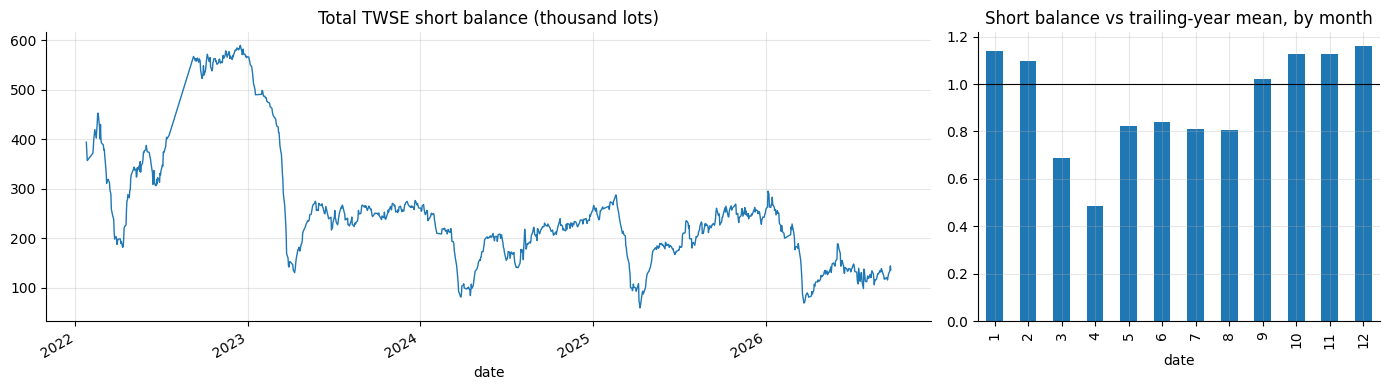

In [3]:
tot = SB.sum(axis=1) / 1e3
fig, ax = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2.2, 1]})
tot.plot(ax=ax[0], lw=1)
ax[0].set_title("Total TWSE short balance (thousand lots)")

seas = (tot / tot.rolling(250, min_periods=60).mean()).groupby(tot.index.month).mean()
seas.plot.bar(ax=ax[1], color="tab:blue")
ax[1].axhline(1, color="k", lw=0.8)
ax[1].set_title("Short balance vs trailing-year mean, by month")
plt.tight_layout(); plt.show()

## 2. Event calendar and the covering deadline

FinMind gives the start and end of each short-sale ban, not the covering deadline itself. Instead of
trusting a rulebook, find it in the data: for every event, the first trading day on which the short
balance falls to ≤5% of its pre-ban level. If the mechanism is forced, that day should sit at a fixed
offset from the ban window.

In [4]:
REASON = [("股東常會", "AGM"), ("股東臨時會", "EGM"), ("除權息", "ex-rights+div"),
          ("除息", "ex-div"), ("除權", "ex-rights")]
def reason_en(s):
    for k, v in REASON:
        if k in s:
            return v
    return "other"

ev = pd.read_csv(DATA / "suspension.csv", dtype={"stock_id": str}, parse_dates=["date", "end_date"]).drop_duplicates()
ev = ev[ev.stock_id.isin(stocks)].reset_index(drop=True)
ev["why"] = ev.reason.map(reason_en)
ev["s_idx"] = cal.searchsorted(ev.date.values)                          # first trading day of the ban
ev["e_idx"] = cal.searchsorted(ev.end_date.values, side="right") - 1    # last trading day of the ban
ev = ev[(ev.s_idx >= 1) & (ev.s_idx < len(cal)) & (ev.e_idx >= ev.s_idx)].reset_index(drop=True)
ev["j"] = ev.stock_id.map(col)
print(ev.why.value_counts().to_string())
print("ban length (trading days):", (ev.e_idx - ev.s_idx + 1).describe()[["mean", "50%", "min", "max"]].to_dict())

why
AGM              2810
ex-div           1920
other             173
ex-rights+div     166
ex-rights          48
ban length (trading days): {'mean': 31.774477232753565, '50%': 4.0, 'min': 1.0, 'max': 1092.0}


1697 events with a visible drain out of 1697 eligible


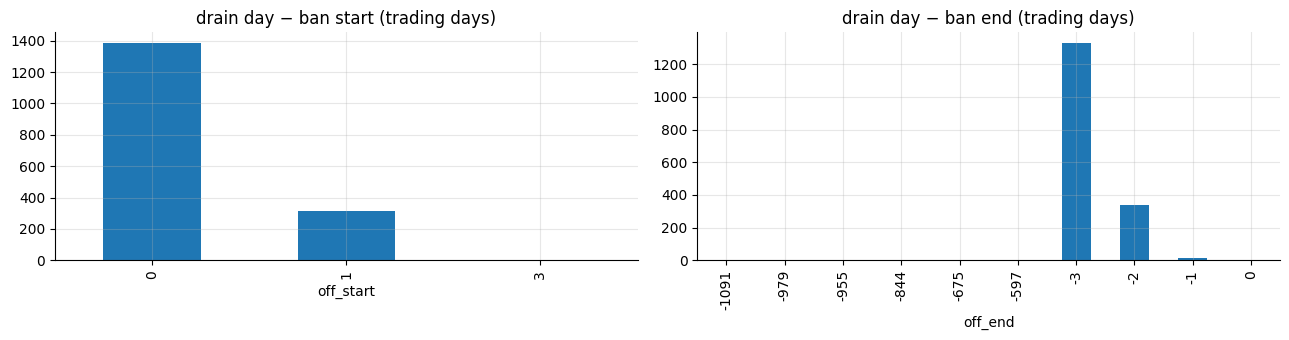

off_start        0    1  3
why                       
AGM            751  181  1
ex-div         516   97  0
ex-rights       13    2  0
ex-rights+div   51   14  0
other           53   18  0


In [5]:
sbv = SB.values
hits = []
for r in ev.itertuples():
    base = sbv[r.s_idx - 1, r.j]
    if not np.isfinite(base) or base < 20:          # need a real short book to see it drain
        continue
    lo, hi = r.s_idx - 1, min(r.e_idx + 5, len(cal) - 1)
    h = np.where(sbv[lo:hi + 1, r.j] <= 0.05 * base)[0]
    if len(h):
        d = lo + h[0]
        hits.append((r.Index, d - r.s_idx, d - r.e_idx))
hits = pd.DataFrame(hits, columns=["i", "off_start", "off_end"]).set_index("i").join(ev[["why"]])
print(f"{len(hits)} events with a visible drain out of {(sbv[ev.s_idx - 1, ev.j] >= 20).sum()} eligible")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
hits.off_start.value_counts().sort_index().plot.bar(ax=ax[0], title="drain day − ban start (trading days)")
hits.off_end.value_counts().sort_index().plot.bar(ax=ax[1], title="drain day − ban end (trading days)")
plt.tight_layout(); plt.show()
print(pd.crosstab(hits.why, hits.off_start).to_string())

Pick whichever anchor (ban start or ban end) gives the tighter distribution, and use its modal offset
per reason as the deadline rule. The rule is learned on **in-sample events only** and then applied to
every event, including ones with no short interest, so the deadline never depends on the outcome.

In [6]:
share = lambda s: s.value_counts(normalize=True).iloc[0]
hits_is = hits[cal[ev.loc[hits.index, "s_idx"].values] <= IS_END]
hits_is = hits_is if len(hits_is) >= 50 else hits       # fall back while the 2018-2023 pull is incomplete
print(f"deadline rule learned on {len(hits_is)} events" + ("" if len(hits_is) < len(hits) else " (ALL events: not enough in-sample yet)"))
ANCHOR = "off_start" if share(hits_is.off_start) >= share(hits_is.off_end) else "off_end"
rule = hits_is.groupby("why")[ANCHOR].agg(lambda s: s.mode().iloc[0])
rule_all = hits_is[ANCHOR].mode().iloc[0]
print("anchor:", ANCHOR, "| modal share:", round(share(hits[ANCHOR]), 3))
print("deadline offset by reason:", rule.to_dict(), "| default:", rule_all)

base_idx = ev.s_idx if ANCHOR == "off_start" else ev.e_idx
ev["D"] = base_idx + ev.why.map(rule).fillna(rule_all).astype(int)
ev = ev[(ev.D >= max(PRE, SIG_LAG) + 1) & (ev.D < len(cal))]

# One event per stock per season: drop a second window whose deadline is within 10 days of the previous one.
ev = ev.sort_values(["stock_id", "D"])
ev = ev[ev.groupby("stock_id").D.diff().fillna(99) >= 10].reset_index(drop=True)
ev["Ddate"] = cal[ev.D.values]
print(f"{len(ev)} events, {ev.Ddate.nunique()} distinct deadline dates")

deadline rule learned on 732 events
anchor: off_start | modal share: 0.816
deadline offset by reason: {'AGM': 0, 'ex-div': 0, 'ex-rights': 0, 'ex-rights+div': 0, 'other': 0} | default: 0
5093 events, 595 distinct deadline dates


### Short pressure at the start of the ban

Measured on day **D−7** (`SIG_LAG`): that balance is published the evening of D−7, a position can be
opened at the close of D−6, and the first return it earns is D−5 — the first day of every window below.
Nothing in the sort can see a return inside the windows.

* `dtc` — days to cover: short balance / 20-day average volume
* `sr` — short/margin ratio (券資比), the retail-trader favourite
* `size` — 20-day average traded value

`sb0` (balance the day before the ban) is kept only to normalise the mechanism plot, never to sort.
Quintiles are formed **within each year**, so a breakpoint never uses later years' short levels.

In [7]:
quint = lambda s: np.ceil(s.rank(method="first", pct=True) * 5)   # 1..5, safe for small groups
sig = ev.D.values - SIG_LAG
J = ev.j.values
ev["sb0"] = SB.values[ev.s_idx.values - 1, J]
ev["sb_sig"] = SB.values[sig, J]
ev["dtc"] = SB.values[sig, J] / ADV.values[sig, J]
ev["sr"] = SB.values[sig, J] / MB.values[sig, J]
ev["size"] = VAL20.values[sig, J]
ev = ev[np.isfinite(ev.dtc) & (ev.sb_sig > 0)].reset_index(drop=True)
ev["q"] = ev.groupby(ev.Ddate.dt.year).dtc.transform(
    quint).astype(int)
ev["oos"] = ev.Ddate > IS_END
print(ev.groupby("q").dtc.describe()[["count", "min", "50%", "max"]])

   count       min       50%       max
q                                     
1  719.0  0.000059  0.002672  0.009978
2  722.0  0.002587  0.010214  0.026870
3  723.0  0.005969  0.024586  0.054608
4  722.0  0.013193  0.055573  0.129560
5  724.0  0.029179  0.149960  5.470389


## 3. Event study around the deadline (day 0 = last covering day)

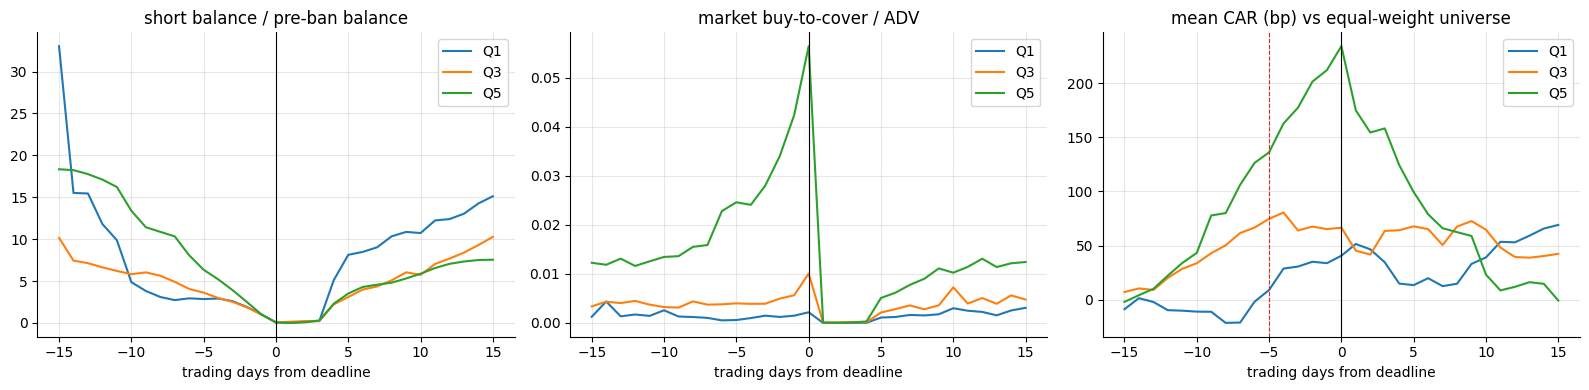

share of pre-deadline covering done by market buys (vs delivering stock): 83.8%


In [8]:
offs = np.arange(-PRE, POST + 1)

def ev_matrix(M, D, J):
    ii = D[:, None] + offs[None, :]
    ok = (ii >= 0) & (ii < M.shape[0])
    out = np.full(ii.shape, np.nan)
    out[ok] = M[ii[ok], np.broadcast_to(J[:, None], ii.shape)[ok]]
    return out

def cumsum0(M):
    # zero-padded cumulative sum so car = C[b+1] - C[a]
    return np.vstack([np.zeros((1, M.shape[1])), np.nancumsum(M, axis=0)])

ARv = AR.values
C_AR = cumsum0(ARv)
def car(D, J, a, b, C=C_AR):
    lo, hi = D + a, D + b + 1
    ok = (lo >= 0) & (hi <= C.shape[0] - 1)
    out = np.full(len(D), np.nan)
    out[ok] = C[hi[ok], J[ok]] - C[lo[ok], J[ok]]
    return out

D, J = ev.D.values, ev.j.values
A = ev_matrix(ARv, D, J)
SBn = ev_matrix(SB.values, D, J) / ev.sb0.where(ev.sb0 > 0).values[:, None]
CF = ev_matrix((COVB.values), D, J) / ADV.values[ev.s_idx.values - 1, J][:, None]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for q in [1, 3, 5]:
    m = ev.q.values == q
    ax[0].plot(offs, np.nanmean(SBn[m], 0), label=f"Q{q}")
    ax[1].plot(offs, np.nanmean(CF[m], 0), label=f"Q{q}")
    ax[2].plot(offs, np.nanmean(np.nancumsum(A[m], 1), 0) * 1e4, label=f"Q{q}")
ax[0].set_title("short balance / pre-ban balance"); ax[1].set_title("market buy-to-cover / ADV")
ax[2].set_title("mean CAR (bp) vs equal-weight universe")
for x in ax: x.axvline(0, color="k", lw=0.8); x.legend(); x.set_xlabel("trading days from deadline")
ax[2].axvline(-SIG_LAG + 2, color="tab:red", ls="--", lw=0.8)   # first return the signal can trade
plt.tight_layout(); plt.show()

buy_share = np.nansum(ev_matrix(COVB.values, D, J)[:, offs <= 0]) / (
    np.nansum(ev_matrix(COVB.values, D, J)[:, offs <= 0]) + np.nansum(ev_matrix(COVR.values, D, J)[:, offs <= 0]))
print(f"share of pre-deadline covering done by market buys (vs delivering stock): {buy_share:.1%}")

### Significance: date-clustered bootstrap

Events bunch on the same deadline dates (AGM season), so event-level t-stats overstate significance.
Resample whole deadline dates instead of events.

In [9]:
def cluster_boot(x, cl, n=2000, seed=0):
    df = pd.DataFrame({"x": x, "c": cl}).dropna()
    g = df.groupby("c").x.agg(["sum", "count"])
    s, c = g["sum"].values, g["count"].values
    b = np.random.default_rng(seed).integers(0, len(g), (n, len(g)))
    boots = s[b].sum(1) / c[b].sum(1)
    m = s.sum() / c.sum()
    return m, boots.std(), m / boots.std(), np.percentile(boots, [2.5, 97.5])

WINDOWS = {"into deadline [-5,0]": (-5, 0), "deadline day [0,0]": (0, 0),
           "after [+1,+5]": (1, 5), "after [+1,+10]": (1, 10)}
assert min(a for a, _ in WINDOWS.values()) >= -SIG_LAG + 2, "a window starts before the signal is tradable"
for name, (a, b) in WINDOWS.items():
    ev[name] = car(D, J, a, b)
    ev[name + " rel"] = ev[name] - ev.groupby("Ddate")[name].transform("mean")   # vs same-deadline peers

def table(df, by, rel=False):
    rows = []
    for key, g in df.groupby(by):
        for name in WINDOWS:
            c = name + " rel" if rel else name
            m, se, t, ci = cluster_boot(g[c].values, g.Ddate.values)
            rows.append({by: key, "window": name, "n": g[c].notna().sum(),
                         "mean_bp": m * 1e4, "t": t, "ci_lo": ci[0] * 1e4, "ci_hi": ci[1] * 1e4})
    return pd.DataFrame(rows).pivot(index=by, columns="window", values=["mean_bp", "t"]).round(2)

def spread(df, qcol="q", hi=5, lo=1):
    # Q5 minus Q1 among events sharing a deadline date; one observation per date, t across dates
    out = {}
    for name in WINDOWS:
        g = df[df[qcol].isin([hi, lo])].groupby(["Ddate", qcol])[name].mean().unstack()
        s = (g[hi] - g[lo]).dropna()
        out[name] = {"Q5-Q1 bp": s.mean() * 1e4, "t": s.mean() / s.std() * np.sqrt(len(s)), "dates": len(s)}
    return pd.DataFrame(out).T.round(2)

print("== CAR vs equal-weight universe")
print(table(ev, "q").to_string())
print("\n== CAR relative to same-deadline peers (seasonality removed)")
print(table(ev, "q", rel=True).to_string())
print("\n== within-date high-minus-low short pressure  <-- the headline test")
print(spread(ev).to_string())

== CAR vs equal-weight universe
              mean_bp                                                                    t                                                      
window after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0] after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0]
q                                                                                                                                               
1                0.09        -25.48               6.87                42.36           0.00         -1.35               0.96                 2.31
2               -3.77          2.10             -12.61                19.41          -0.13          0.11              -1.56                 1.07
3               -1.30          1.80               1.29                -0.14          -0.04          0.09               0.16                -0.01
4              -90.13        -66.38              -5.78                26.72          -2.61        

              mean_bp                                                                    t                                                      
window after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0] after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0]
q                                                                                                                                               
1               70.63         21.20               3.45                 1.56           2.68          1.33               0.52                 0.09
2               42.31         42.96             -14.04               -23.21           1.66          2.67              -2.04                -1.34
3               76.90         54.38              -0.06               -24.84           2.77          3.22              -0.01                -1.27
4              -37.85        -27.26             -10.27                -9.29          -1.28         -1.64              -1.27       

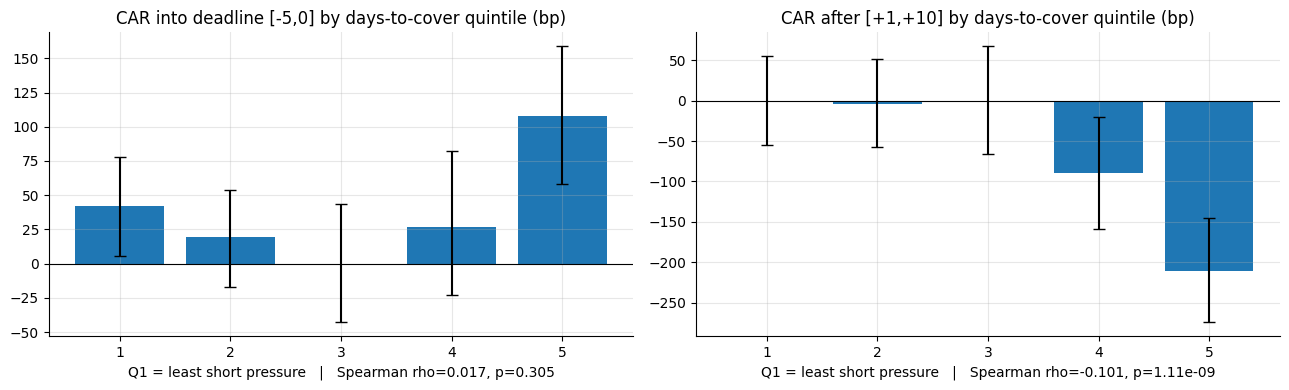

In [10]:
# Monotonicity across quintiles (crop-pitch style) + Spearman on the event level
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, name in enumerate(["into deadline [-5,0]", "after [+1,+10]"]):
    stats = [cluster_boot(g[name].values, g.Ddate.values) for _, g in ev.groupby("q")]
    m = np.array([s[0] for s in stats]) * 1e4
    lo = np.array([s[3][0] for s in stats]) * 1e4; hi = np.array([s[3][1] for s in stats]) * 1e4
    ax[k].bar(range(1, 6), m, yerr=[m - lo, hi - m], capsize=4)
    ax[k].axhline(0, color="k", lw=0.8); ax[k].set_title(f"CAR {name} by days-to-cover quintile (bp)")
    rho, p = st.spearmanr(ev.dtc, ev[name], nan_policy="omit")
    ax[k].set_xlabel(f"Q1 = least short pressure   |   Spearman rho={rho:.3f}, p={p:.3g}")
plt.tight_layout(); plt.show()

### Within-date long-short

AGM season has its own market-wide drift. Demeaning each event's CAR by the mean CAR of all events
sharing the same deadline date removes anything common to that date, leaving only the cross-sectional
effect of short pressure. Standard errors clustered by date.

In [11]:
for name in ["into deadline [-5,0]", "after [+1,+5]", "after [+1,+10]"]:
    d = ev[["Ddate", "dtc", "sr", "size", name]].dropna().rename(columns={name: "y"})
    d["y"] = (d.y - d.groupby("Ddate").y.transform("mean")) * 1e4
    d["dtc_rank"] = d.groupby("Ddate").dtc.rank(pct=True)
    d["ldtc"] = np.log1p(d.dtc)
    d["lsize"] = np.log(d["size"])
    fit = smf.ols("y ~ dtc_rank + lsize", d).fit(cov_type="cluster", cov_kwds={"groups": d.Ddate.factorize()[0]})
    print(f"== {name}  (bp, demeaned by deadline date)")
    print(fit.summary().tables[1])

== into deadline [-5,0]  (bp, demeaned by deadline date)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -181.0436     95.604     -1.894      0.058    -368.425       6.337
dtc_rank      44.6372     32.773      1.362      0.173     -19.597     108.871
lsize          8.3954      4.882      1.720      0.085      -1.173      17.964
== after [+1,+5]  (bp, demeaned by deadline date)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    220.7385     82.478      2.676      0.007      59.084     382.393
dtc_rank    -123.3472     26.310     -4.688      0.000    -174.914     -71.781
lsize         -8.0925      4.231     -1.912      0.056     -16.386       0.201
== after [+1,+10]  (bp, demeaned by deadline date)
                 coef    std err          z      P>|

### Panel regression: does *remaining* short pressure predict tomorrow's return — only inside the window?

For every stock-day: `AR_t ~ P_{t-2} × (PRE_t + POST_t)`, where `P = log(1 + short balance / ADV)`.
`PRE` marks the 5 days up to and including the deadline, `POST` the 10 days after it; both are known in
advance from the ban calendar. `P` is lagged **two** days because the balance of day *t−1* is published
after that close. The interactions are the thesis: the same short interest should only predict returns
around a forced cover. Clustered by date.

In [12]:
PREW = np.zeros(AR.shape, dtype=bool); POSTW = np.zeros(AR.shape, dtype=bool)
for d_, j in zip(ev.D.values, ev.j.values):
    PREW[max(d_ - 5, 0):d_ + 1, j] = True
    POSTW[d_ + 1:d_ + 11, j] = True
POSTW &= ~PREW

P = np.log1p((SB / ADV).shift(2)).values
P = np.clip(P, 0, np.nanpercentile(P, 99.5))
T_, N_ = AR.shape
panel = pd.DataFrame({"ar": ARv.ravel() * 1e4, "P": P.ravel(), "PRE": PREW.ravel().astype(int),
                      "POST": POSTW.ravel().astype(int), "t": np.repeat(np.arange(T_), N_)}).dropna()
fit = smf.ols("ar ~ P * (PRE + POST)", panel).fit(cov_type="cluster", cov_kwds={"groups": panel.t.values})
print(f"{len(panel):,} stock-days, {panel.PRE.sum():,} pre-deadline, {panel.POST.sum():,} post-deadline")
print(fit.summary().tables[1])

1,070,893 stock-days, 21,652 pre-deadline, 35,790 post-deadline
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2967      0.297      0.998      0.318      -0.286       0.879
P             -3.1079      5.324     -0.584      0.559     -13.544       7.328
PRE            3.2952      1.931      1.707      0.088      -0.489       7.079
POST          -5.5327      1.710     -3.236      0.001      -8.884      -2.182
P:PRE         65.8329     19.122      3.443      0.001      28.354     103.312
P:POST       -58.8641     26.554     -2.217      0.027    -110.909      -6.819


## 4. Placebos (Gotobi-style)

Both run on the headline statistic — the within-date Q5−Q1 spread — for the pre-deadline window and the
post-deadline reversal window.

1. **Calendar shift.** Move every event (and its D−7 signal) by *k* trading days (k = −40…40), re-sort,
   and recompute the spread. If the effect is about the deadline, k = 0 should stand out, not sit inside
   a smooth hump — a hump means the sort is just picking up generic short-interest / momentum effects.
2. **Random dates.** Give every event a random fake deadline 21–120 trading days away (same stock), build
   the D−7 signal and quintiles on the fake date exactly as for the real one, 500 times. Where does the
   real spread land in that null?

into deadline [-5,0]   real spread    26.3bp | null mean   -2.9bp sd  54.3 | p=0.586


after [+1,+10]         real spread  -266.1bp | null mean   10.6bp sd  66.1 | p=0.000


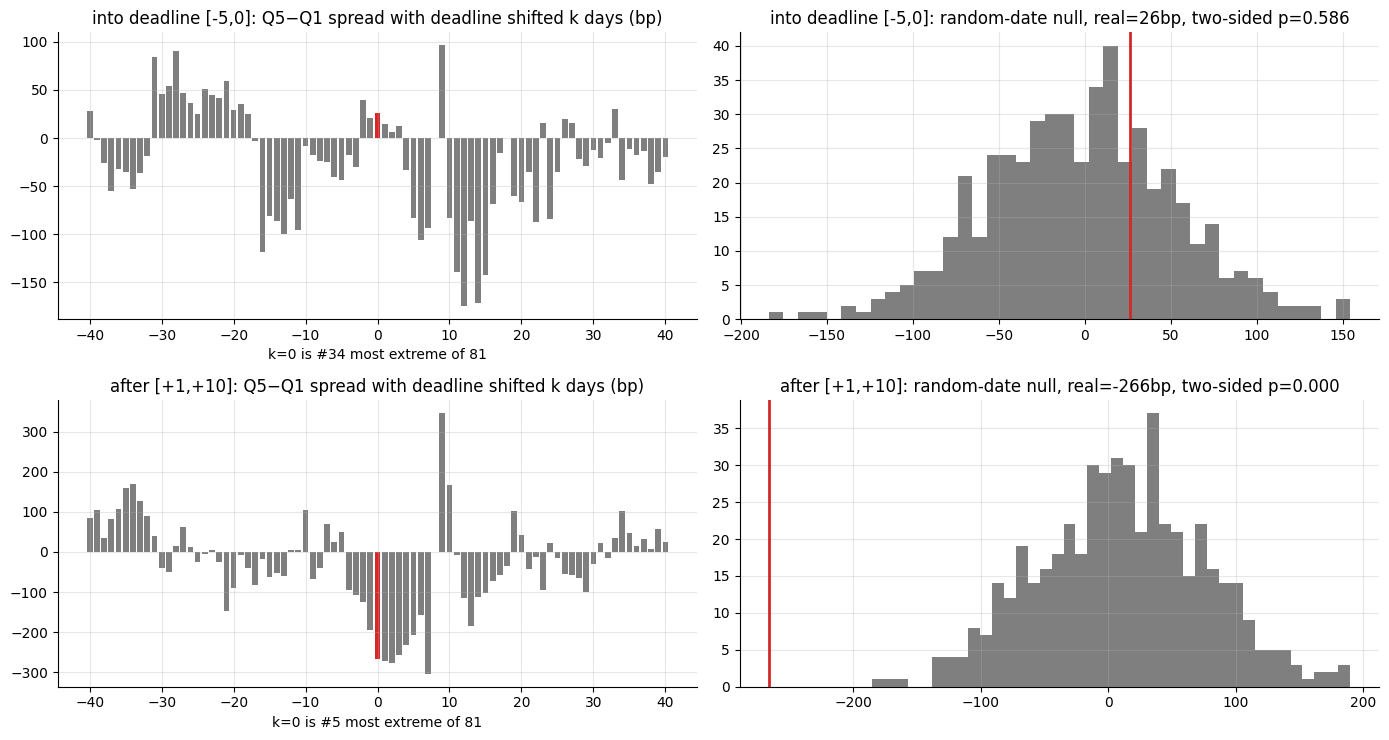

In [13]:
def spread_at(Dx, Jx, years, a, b):
    s = Dx - SIG_LAG
    ok = (s >= 0) & (Dx + b < len(cal))
    x = pd.DataFrame({"Dx": Dx[ok], "yr": years[ok], "dtc": SB.values[s[ok], Jx[ok]] / ADV.values[s[ok], Jx[ok]],
                      "sb": SB.values[s[ok], Jx[ok]], "w": car(Dx[ok], Jx[ok], a, b)})
    x = x[np.isfinite(x.dtc) & (x.sb > 0)]
    x["q"] = x.groupby("yr").dtc.transform(quint).astype(int)
    g = x[x.q.isin([1, 5])].groupby(["Dx", "q"]).w.mean().unstack().reindex(columns=[1, 5])
    return (g[5] - g[1]).mean() * 1e4

D0, J0, Y0 = ev.D.values, ev.j.values, ev.Ddate.dt.year.values
fig, ax = plt.subplots(2, 2, figsize=(14, 7.5))
rng = np.random.default_rng(1)
for r, name in enumerate(["into deadline [-5,0]", "after [+1,+10]"]):
    a, b = WINDOWS[name]
    ks = np.arange(-40, 41)
    sh = np.array([spread_at(D0 + k, J0, Y0, a, b) for k in ks])
    real = sh[ks == 0][0]
    ext = (np.abs(sh - np.nanmedian(sh)) >= abs(real - np.nanmedian(sh))).sum()
    ax[r, 0].bar(ks, sh, color=np.where(ks == 0, "tab:red", "tab:gray"))
    ax[r, 0].set_title(f"{name}: Q5−Q1 spread with deadline shifted k days (bp)")
    ax[r, 0].set_xlabel(f"k=0 is #{ext} most extreme of {len(ks)}")
    null = np.array([spread_at(D0 + rng.integers(21, 121, len(D0)) * rng.choice([-1, 1], len(D0)), J0, Y0, a, b)
                     for _ in range(500)])
    p = np.mean(np.abs(null - np.nanmean(null)) >= abs(real - np.nanmean(null)))
    ax[r, 1].hist(null, bins=40, color="tab:gray"); ax[r, 1].axvline(real, color="tab:red", lw=2)
    ax[r, 1].set_title(f"{name}: random-date null, real={real:.0f}bp, two-sided p={p:.3f}")
    print(f"{name:22s} real spread {real:7.1f}bp | null mean {np.nanmean(null):6.1f}bp sd {np.nanstd(null):5.1f} | p={p:.3f}")
plt.tight_layout(); plt.show()

## 5. Robustness splits

In [14]:
ev["year"] = ev.Ddate.dt.year
ev["size_t"] = pd.qcut(ev["size"].rank(method="first"), 3, labels=["small", "mid", "large"])
hi = ev[ev.q == 5]
for by in ["why", "year", "size_t", "oos"]:
    print(f"\n==== Q5 (highest days-to-cover) by {by}, relative to same-deadline peers")
    print(table(hi, by, rel=True).to_string())
for by in ["year", "oos", "why"]:
    print(f"\n==== within-date Q5−Q1 spread by {by}")
    for key, g in ev.groupby(by):
        print(f"-- {key}\n" + spread(g).to_string())


==== Q5 (highest days-to-cover) by why, relative to same-deadline peers
                     mean_bp                                                                    t                                                      
window        after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0] after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0]
why                                                                                                                                                    
AGM                  -146.99        -85.81              14.83                52.85          -5.04         -4.22               1.76                 2.21
ex-div               -159.91       -102.80              34.57                54.34          -2.98         -2.93               2.57                 1.71
ex-rights              85.17        195.20             -49.39               302.43           0.92          2.19              -1.12                 1.05
ex-rights+div  

-- ex-div
                      Q5-Q1 bp     t  dates
into deadline [-5,0]     22.72  0.33   75.0
deadline day [0,0]       20.35  0.69   75.0
after [+1,+5]          -192.33 -2.53   75.0
after [+1,+10]         -379.71 -3.26   75.0
-- ex-rights
                      Q5-Q1 bp   t  dates
into deadline [-5,0]       NaN NaN    0.0
deadline day [0,0]         NaN NaN    0.0
after [+1,+5]              NaN NaN    0.0
after [+1,+10]             NaN NaN    0.0
-- ex-rights+div
                      Q5-Q1 bp     t  dates
into deadline [-5,0]    719.02  2.01    5.0
deadline day [0,0]      202.27  1.62    5.0
after [+1,+5]          -146.47 -0.54    5.0
after [+1,+10]        -1115.76 -2.26    5.0
-- other
                      Q5-Q1 bp     t  dates
into deadline [-5,0]    578.49  1.04    3.0
deadline day [0,0]      235.55  0.77    3.0
after [+1,+5]            17.08  0.05    3.0
after [+1,+10]         -268.99 -0.47    3.0


In [15]:
# Short/margin ratio (券資比) as the alternative sort -- the measure Taiwanese retail actually watches
ev["q_sr"] = ev.groupby(ev.Ddate.dt.year).sr.transform(
    quint).astype(int)
print(table(ev, "q_sr", rel=True).to_string())
print(spread(ev, "q_sr").to_string())

              mean_bp                                                                    t                                                      
window after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0] after [+1,+10] after [+1,+5] deadline day [0,0] into deadline [-5,0]
q_sr                                                                                                                                            
1               44.94         29.30              -0.87                 1.41           1.83          2.13              -0.14                 0.09
2               34.43         31.53              -7.93               -37.14           1.51          2.06              -1.30                -2.66
3               20.07         30.69              -3.55               -41.13           0.80          1.99              -0.53                -2.54
4              -11.09         -9.33               2.12                 4.57          -0.50         -0.58               0.31       

## 6. Tradability: stock futures

Selling stock costs 0.3% tax; stock futures cost ~0.002%. Build a front-month return series per
underlying (contract with the highest open interest the day before, returns within the same contract so
rolls don't create jumps), then check the effect survives in the futures.

Caveat: TAIFEX adjusts a stock future for cash dividends by re-coding the old contracts, so a window
that crosses the ex-date can lose its series. The covering deadline falls before the ex-date, so the
window into the deadline is unaffected — but the post-deadline window often *does* cross the ex-date,
so check how many post-deadline trades survive in futures.

Both stock and futures returns here are TAIEX-hedged (`AR_TX`), because that is the P&L you can earn.

In [16]:
HAVE_FUT = (DATA / "stock_futures.csv").exists() and (DATA / "futures_map.csv").exists()
if not HAVE_FUT:
    print("stock_futures.csv not pulled yet -- futures legs are skipped below")
    FAR = pd.DataFrame(np.nan, index=cal, columns=stocks)
    ev["has_fut"] = False

stock_futures.csv not pulled yet -- futures legs are skipped below


In [17]:
assert HAVE_FUT, "futures data not available yet"
fu = pd.read_csv(DATA / "stock_futures.csv", dtype={"futures_id": str, "contract_date": str}, parse_dates=["date"])
fu = fu[~fu.contract_date.str.contains("/")]
fu["px"] = fu.close.where(fu.close > 0, fu.settlement_price)
fu = fu[fu.px > 0].sort_values(["futures_id", "contract_date", "date"])
g = fu.groupby(["futures_id", "contract_date"])
fu["r"] = g.px.pct_change(fill_method=None)
fu["oi_prev"] = g.open_interest.shift()
front = fu.dropna(subset=["r", "oi_prev"]).sort_values("oi_prev").groupby(["futures_id", "date"]).tail(1)

fmap = pd.read_csv(DATA / "futures_map.csv", dtype=str)
fmap["futures_id"] = fmap.prefix + "F"
front = front.merge(fmap[["futures_id", "stock_id"]], on="futures_id")
front.loc[front.r.abs() > 0.105, "r"] = np.nan
FR = front.pivot_table(index="date", columns="stock_id", values="r").reindex(index=cal, columns=stocks)
FAR = FR.sub(mkt, axis=0)
C_FAR = cumsum0(FAR.values)
fut_cov = FR.notna().rolling(20, min_periods=1).sum().values > 10     # has a live futures series

ev["has_fut"] = fut_cov[ev.D.values, ev.j.values]
C_TX = cumsum0(AR_TX.values)
rows = {}
for name in ["into deadline [-5,0]", "after [+1,+10]"]:
    a, b = WINDOWS[name]
    fc = pd.Series(car(ev.D.values, ev.j.values, a, b, C=C_FAR)).where(ev.has_fut)
    sc = pd.Series(car(ev.D.values, ev.j.values, a, b, C=C_TX)).where(fc.notna())
    print(f"{name}: {fc.notna().sum()} events with a futures series ({(fc.notna() & (ev.q == 5)).sum()} in Q5), "
          f"corr(stock, futures) = {sc.corr(fc):.3f}")
    rows[(name, "stock bp")] = sc.groupby(ev.q).mean() * 1e4
    rows[(name, "futures bp")] = fc.groupby(ev.q).mean() * 1e4
pd.DataFrame(rows).round(1)

AssertionError: futures data not available yet

### Backtest grid

Two rules, both TAIEX-hedged (short TX against a long, long TX against a short):

* **Long into the deadline:** buy at the close of `D−k`, sell at the close of `D+h`.
* **Short the reversal:** short at the close of `D+k`, cover at the close of `D+k+h`. A *stock* short
  cannot be opened with margin while the ban is on, so it waits for the ban to end; a *futures* short
  can go on straight away.

Signal = days-to-cover from the last balance published before entry and never later than D−7 (the same
pre-drain balance the event study sorts on), must exceed the **in-sample** 80th percentile, and the
stock must trade ≥ NT$20m/day. Daily P&L
is the equal-weight average of open positions, cost charged on exit. Grid picked on in-sample years only.

1416 in-sample events (2022-03-04 -> 2023-12-31), 2194 out-of-sample; days-to-cover threshold 0.129


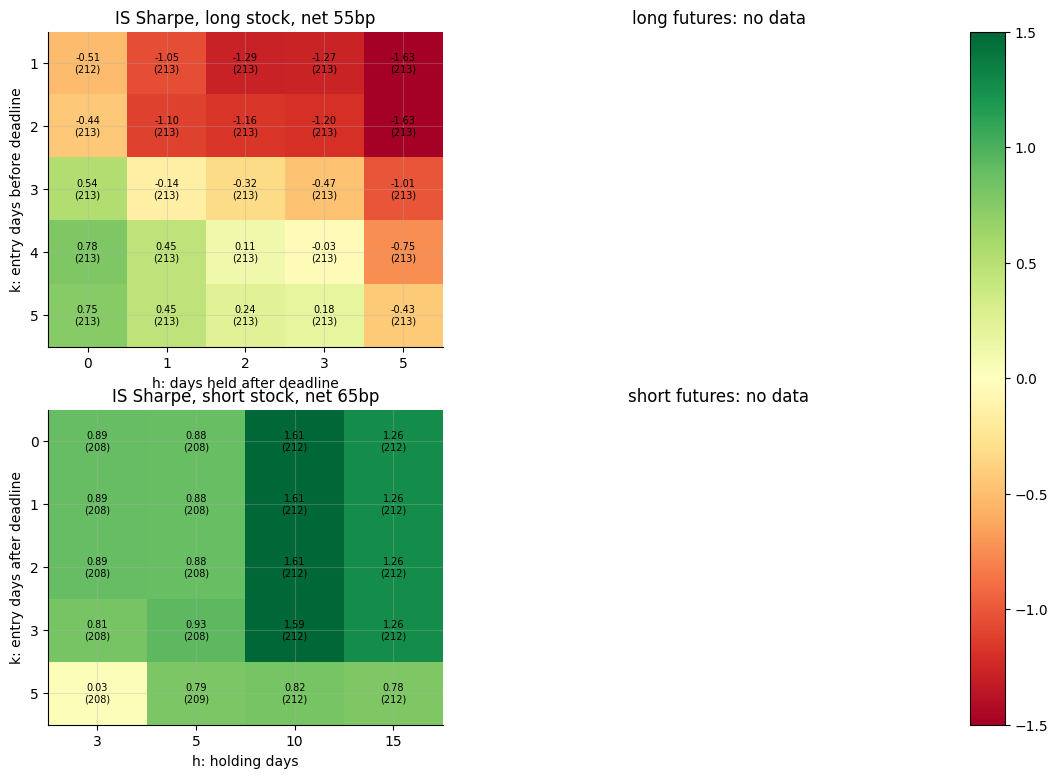

In [18]:
def backtest(evs, side, k, h, M, cost_bps, thr, wait_ban_end=False):
    T = len(cal)
    Mv = np.nan_to_num(M)
    D_, S_, E_, J_ = evs.D.values, evs.s_idx.values, evs.e_idx.values, evs.j.values
    entry = D_ - k if side == "long" else D_ + k
    if wait_ban_end:
        entry = np.maximum(entry, E_ + 1)                     # first day a margin short can be opened
    exit_ = entry + (k + h if side == "long" else h)
    # same pre-drain balance the event study sorts on; most shorts are gone before the ban starts
    sig = np.clip(np.minimum(entry - 1, D_ - SIG_LAG), 0, T - 1)
    dtc = SB.values[sig, J_] / ADV.values[sig, J_]
    liq = VAL20.values[sig, J_] >= MIN_VAL20
    sgn = 1 if side == "long" else -1
    psum, pcnt, trades = np.zeros(T), np.zeros(T), []
    for lo, hi, j_, x, ok in zip(entry + 1, exit_, J_, dtc, liq):
        if not (x >= thr) or not ok or lo < 1 or hi >= T or np.isnan(M[lo:hi + 1, j_]).all():
            continue
        rr = sgn * Mv[lo:hi + 1, j_]
        rr[-1] -= cost_bps / 1e4
        psum[lo:hi + 1] += rr; pcnt[lo:hi + 1] += 1
        trades.append(rr.sum())
    daily = pd.Series(np.divide(psum, pcnt, out=np.zeros(T), where=pcnt > 0), cal)
    return daily, np.array(trades)

def sharpe(x):
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else np.nan

ins, oos = ev[~ev.oos], ev[ev.oos]
THR = ins.dtc.quantile(0.8)
print(f"{len(ins)} in-sample events ({ins.Ddate.min().date()} -> {IS_END.date()}), {len(oos)} out-of-sample; "
      f"days-to-cover threshold {THR:.3f}")

STRATS = [  # label, side, k grid, h grid, return matrix, cost, wait for ban end, universe
    ("long stock",     "long",  [1, 2, 3, 4, 5], [0, 1, 2, 3, 5], AR_TX.values, COST_STOCK_BPS, False, lambda e: e),
    ("long futures",   "long",  [1, 2, 3, 4, 5], [0, 1, 2, 3, 5], FAR.values,   COST_FUT_BPS,   False, lambda e: e[e.has_fut]),
    ("short stock",    "short", [0, 1, 2, 3, 5], [3, 5, 10, 15],  AR_TX.values, COST_SHORT_BPS, True,  lambda e: e),
    ("short futures",  "short", [0, 1, 2, 3, 5], [3, 5, 10, 15],  FAR.values,   COST_FUT_BPS,   False, lambda e: e[e.has_fut]),
]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
grids = {}
for ax, (label, side, K, H, M, cost, wait, uni) in zip(axes.ravel(), STRATS):
    evs = uni(ins)
    if evs.empty:
        ax.set_title(f"{label}: no data"); ax.axis("off"); continue
    sh = pd.DataFrame(index=K, columns=H, dtype=float); nt = sh.copy()
    for k in K:
        for h in H:
            d, t = backtest(evs, side, k, h, M, cost, THR, wait)
            sh.loc[k, h] = sharpe(d[d.index <= IS_END]); nt.loc[k, h] = len(t)
    grids[label] = (sh, nt)
    im = ax.imshow(sh.values, cmap="RdYlGn", aspect="auto", vmin=-1.5, vmax=1.5)
    ax.set_xticks(range(len(H)), H); ax.set_yticks(range(len(K)), K)
    ax.set_xlabel("h: days held after deadline" if side == "long" else "h: holding days")
    ax.set_ylabel("k: entry days before deadline" if side == "long" else "k: entry days after deadline")
    for (i, jj), v in np.ndenumerate(sh.values):
        ax.text(jj, i, f"{v:.2f}\n({int(nt.values[i, jj])})", ha="center", va="center", fontsize=7)
    ax.set_title(f"IS Sharpe, {label}, net {cost}bp")
plt.colorbar(im, ax=axes); plt.show()

OOS long stock     k=4 h=0: trades=113, mean/trade=-27.1bp net, hit=40.7%, Sharpe=0.33  (IS Sharpe 0.78)
OOS short stock    k=0 h=10: trades=112, mean/trade=65.0bp net, hit=58.9%, Sharpe=-0.16  (IS Sharpe 1.61)


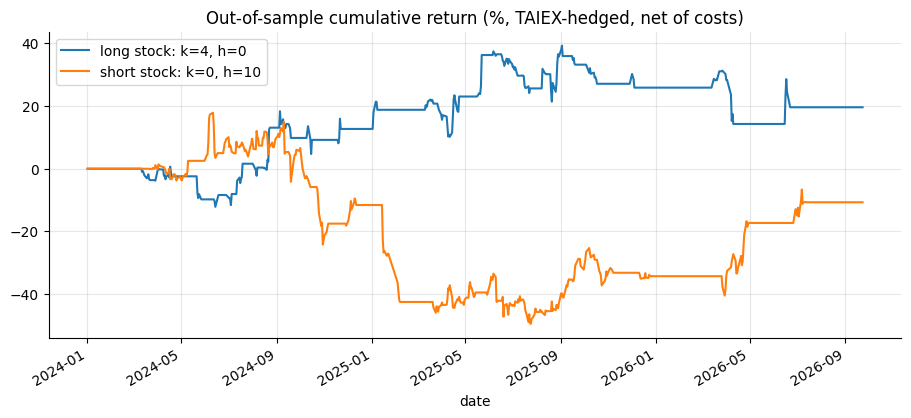

In [19]:
MIN_TRADES = 50
fig, ax = plt.subplots(figsize=(11, 4.5))
for label, side, K, H, M, cost, wait, uni in STRATS:
    if label not in grids:
        continue
    sh, nt = grids[label]
    ok = sh.where(nt >= MIN_TRADES).stack().dropna()
    if ok.empty:
        print(f"{label}: no grid cell has {MIN_TRADES}+ in-sample trades; using the best cell regardless")
        ok = sh.stack().dropna()
    if ok.empty:
        continue
    k, h = ok.idxmax()
    d, t = backtest(uni(oos), side, k, h, M, cost, THR, wait)
    d = d[d.index > IS_END]
    if len(t) == 0:
        print(f"OOS {label:14s}: no trades"); continue
    d.cumsum().mul(100).plot(ax=ax, label=f"{label}: k={k}, h={h}")
    print(f"OOS {label:14s} k={k} h={h}: trades={len(t)}, mean/trade={t.mean()*1e4:.1f}bp net, "
          f"hit={np.mean(t > 0):.1%}, Sharpe={sharpe(d):.2f}  (IS Sharpe {sh.loc[k, h]:.2f})")
ax.set_title("Out-of-sample cumulative return (%, TAIEX-hedged, net of costs)"); ax.legend(); plt.show()

## 7. Notes / what to check next

* If the deadline rule has two modes (e.g. before/after a rule change), split events by period and use
  the per-period mode.
* Futures only cover ~300 names — mostly large caps — so check whether the effect lives in small caps
  that have no futures. If it does, the trade is day-trade-tax (0.15%) or nothing.
* Retail front-running: compare the spread by year; a trend towards the effect moving earlier (or
  vanishing) means the trade is getting crowded.
* The ban calendar's *announcement* date is not in the data. `SIG_LAG = 7` assumes the ban is public at
  least a week ahead (book-closure dates are set with the AGM notice, weeks earlier); confirm this with a
  few TWSE announcements before relying on the pre-deadline windows.
* Equal-weight vs TAIEX: if the event-study effect only shows up against the equal-weight universe, the
  tradable version needs a hedge that looks like the stocks (mid-cap index futures or a peer basket), not TX.
* Borrow-side alternative (借券 SBL) short sellers are *not* forced to cover. If SBL balances rise while
  margin shorts fall, the covering is partly being replaced, not removed.